In [1]:
import xarray as xr
import rioxarray
import geopandas as gpd

import matplotlib.pyplot as plt

In [2]:
ARCHIVO_NC = "../data/raw/ECMWF_utci_2022_mexico_anual.nc"

SHAPEFILE = "../data/raw/INEGI/00ent.shp"

SALIDA = "utci_2022_solo_mexico.nc"

In [3]:
ds = xr.open_dataset(ARCHIVO_NC)

ds

<xarray.Dataset> Size: 359MB
Dimensions:  (time: 8760, lat: 77, lon: 133)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2022-01-01 ... 2022-12-31T23:00:00
  * lat      (lat) float64 616B 33.0 32.75 32.5 32.25 ... 14.75 14.5 14.25 14.0
  * lon      (lon) float64 1kB -119.0 -118.8 -118.5 ... -86.5 -86.25 -86.0
Data variables:
    utci     (time, lat, lon) float32 359MB ...
Attributes:
    CDI:                       Climate Data Interface version 1.9.8 (https://...
    Conventions:               CF-1.6
    institution:               European Centre for Medium-Range Weather Forec...
    CDO:                       Climate Data Operators version 1.9.8 (https://...
    cdo_openmp_thread_number:  8
    history:                   Mon Apr  4 07:54:18 2022: ncatted -a _FillValu...
    NCO:                       netCDF Operators version 4.7.8 (Homepage = htt...

In [4]:
mexico = gpd.read_file(SHAPEFILE)

mexico = mexico.to_crs("EPSG:4326")

mexico = mexico.dissolve()
mexico

,geometry,CVEGEO,CVE_ENT,NOMGEO
0,"MULTIPOLYGON (((-114.7298 18.36779, -114.72854...",01,01,Aguascalientes


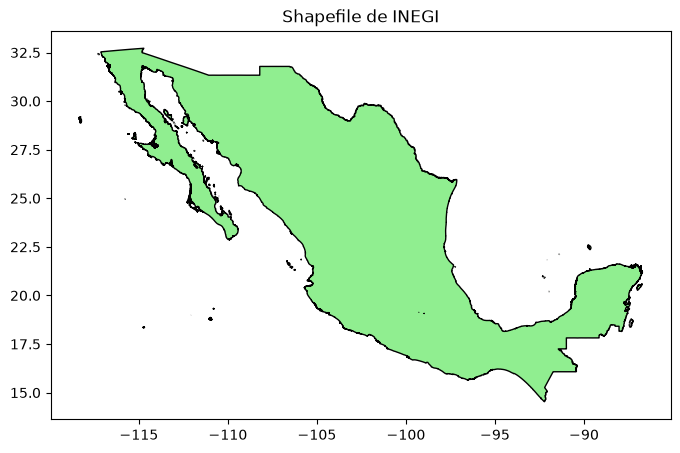

In [5]:
fig, ax = plt.subplots(figsize=(8,8))

mexico.plot(
    ax=ax,
    facecolor="lightgreen",
    edgecolor="black"
)

plt.title("Shapefile de INEGI")

plt.show()

In [6]:
ds = ds.rio.write_crs("EPSG:4326")

In [7]:
ds_mexico = ds.rio.clip(
    mexico.geometry,
    mexico.crs,
    drop=False
)

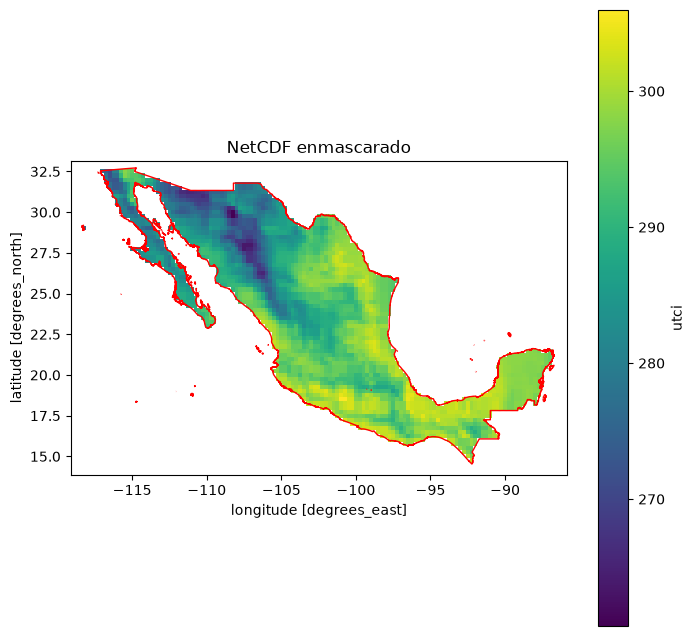

In [8]:
variable = list(ds.data_vars)[0]

fig, ax = plt.subplots(figsize=(8,8))

ds_mexico[variable].isel(time=0).plot(ax=ax)

mexico.boundary.plot(
    ax=ax,
    color="red",
    linewidth=1
)

plt.title("NetCDF enmascarado")

plt.show()

In [9]:
print("Original")

print(ds[variable].isel(time=0).count().values)

print()

print("México")

print(ds_mexico[variable].isel(time=0).count().values)

Original
10241

México
2798
